### 1. Importing the libraries. Loading and preprocessing the dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

In [2]:
# load the dataset
df=pd.read_csv('iris.csv')

In [3]:
print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
df.groupby('Species').size()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

In [5]:
# Display the summary of the dataset
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [6]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [7]:
# Drop Unnecessary Columns
df = df.drop(columns=['Id'])

In [8]:
# Convert categorical data to numerical data
# Label Encoding
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### 2. Feature Selection, Normalisation and Train-Test Split

In [10]:
# Feature Selection
X = df.drop('Species', axis=1)
y = df['Species']

In [11]:
# Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Split data into training and testing sets (75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [13]:
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (112, 4)
Testing set: (38, 4)


### 3. Train & Evaluate KNN Model

In [14]:
# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5) # Try value of K as 5
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [16]:
# Train and evaluate KNN with different k values
accuracies = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

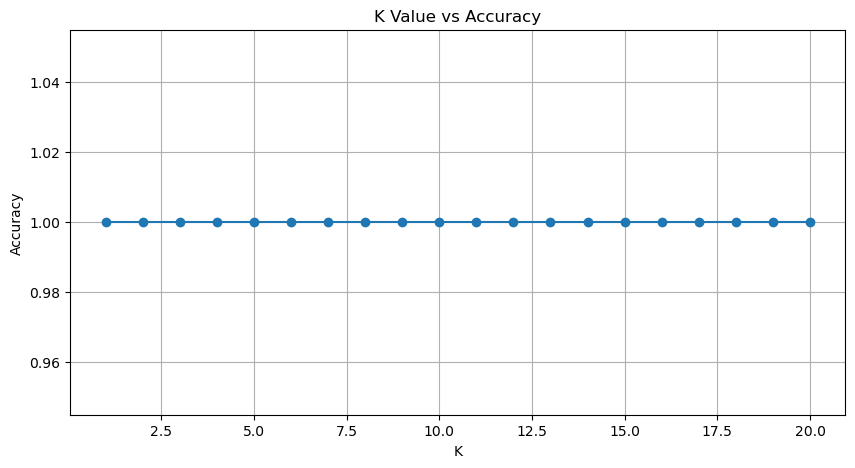

In [17]:
# Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title('K Value vs Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [18]:
# Final model
best_k = k_range[np.argmax(accuracies)]
print(f"Best K: {best_k} with Accuracy: {max(accuracies):.2f}")

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
final_pred = final_knn.predict(X_test)

Best K: 1 with Accuracy: 1.00


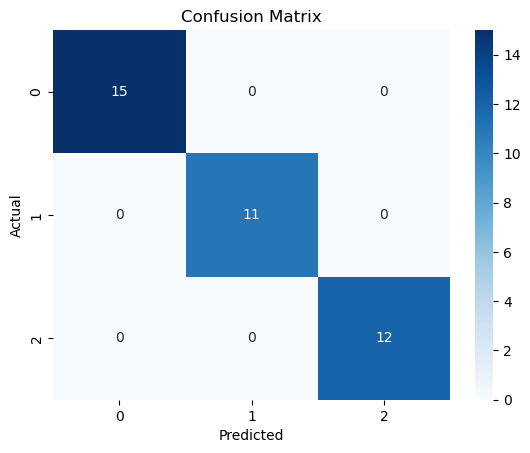

In [19]:
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=final_knn.classes_, yticklabels=final_knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 5. Visualizing Decision Boundaries

Visualizing decision boundaries in KNN helps to understand how the model separates different classes. Since the Iris dataset has 4 features, we’ll reduce it to 2 dimensions by selecting just two features
for visualization.

#### a. Sepal

In [20]:
# Use only two features for visualization (Sepal)
X_sepal = df[['SepalLengthCm', 'SepalWidthCm']].values
y_sepal = df['Species'].values

In [21]:
# Normalize
scaler = StandardScaler()
X_sepal_scaled = scaler.fit_transform(X_sepal)

In [22]:
knn_sepal = KNeighborsClassifier(n_neighbors=1)
knn_sepal.fit(X_sepal_scaled, y_sepal)

KNeighborsClassifier(n_neighbors=1)

In [23]:
# Create meshgrid
x_min, x_max = X_sepal_scaled[:, 0].min() - 1, X_sepal_scaled[:, 0].max() + 1
y_min, y_max = X_sepal_scaled[:, 1].min() - 1, X_sepal_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_sepal.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

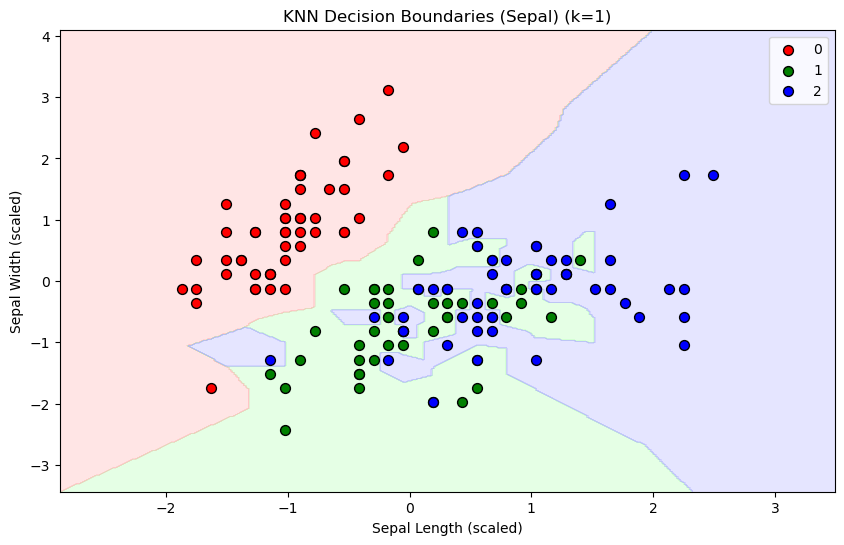

In [24]:
# Plotting
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for idx, class_label in enumerate(np.unique(y_sepal)):
    plt.scatter(X_sepal_scaled[y_sepal == class_label, 0],
                X_sepal_scaled[y_sepal == class_label, 1],
                c=cmap_bold[idx], label=class_label, edgecolor='k', s=50)
    
plt.title("KNN Decision Boundaries (Sepal) (k=1)")
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.legend()
plt.show()

#### b. Petal

In [25]:
# Use only two features for visualization (Petal)
X_petal = df[['PetalLengthCm', 'PetalWidthCm']].values
y_petal = df['Species'].values

In [26]:
# Normalize
scaler = StandardScaler()
X_petal_scaled = scaler.fit_transform(X_petal)

In [27]:
knn_sepal = KNeighborsClassifier(n_neighbors=1)
knn_sepal.fit(X_petal_scaled, y_petal)

KNeighborsClassifier(n_neighbors=1)

In [28]:
# Create meshgrid
x_min, x_max = X_petal_scaled[:, 0].min() - 1, X_petal_scaled[:, 0].max() + 1
y_min, y_max = X_petal_scaled[:, 1].min() - 1, X_petal_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_sepal.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

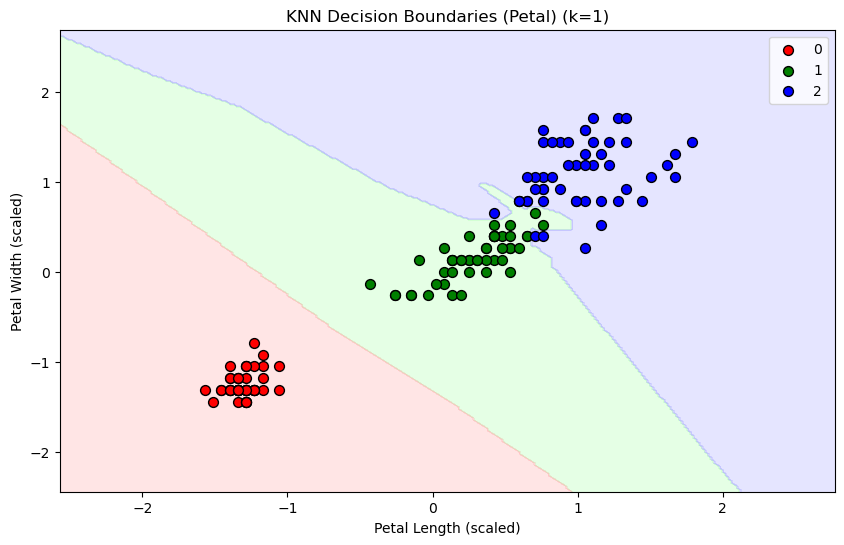

In [29]:
# Plotting
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for idx, class_label in enumerate(np.unique(y_petal)):
    plt.scatter(X_petal_scaled[y_petal == class_label, 0],
                X_petal_scaled[y_petal == class_label, 1],
                c=cmap_bold[idx], label=class_label, edgecolor='k', s=50)
    
plt.title("KNN Decision Boundaries (Petal) (k=1)")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.legend()
plt.show()

#### c. Visualizing KNN Decision Boundaries Using PCA (All Features)

In [30]:
# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [31]:
# Fit KNN model on PCA-reduced data
knn_pca = KNeighborsClassifier(n_neighbors=1)
knn_pca.fit(X_pca, y)

KNeighborsClassifier(n_neighbors=1)

In [32]:
# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

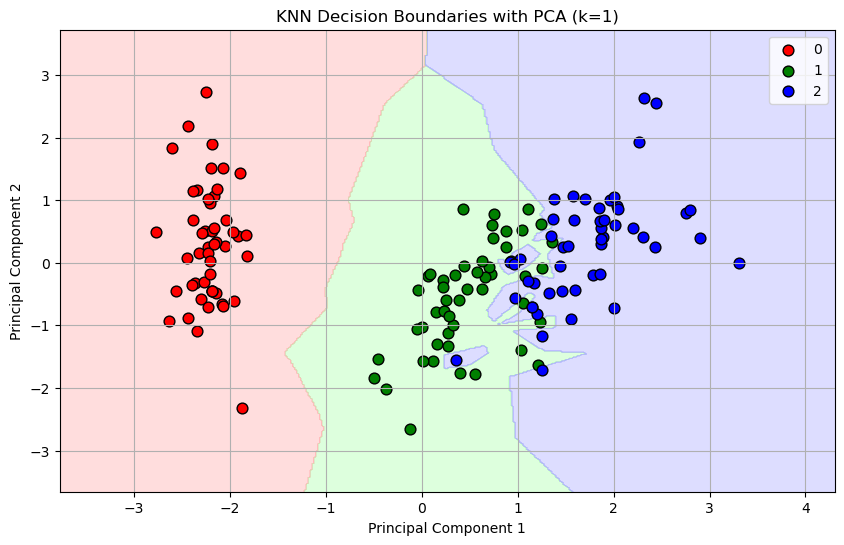

In [36]:
# Plot decision boundary
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)
for idx, class_label in enumerate(np.unique(y)):
    plt.scatter(X_pca[y == class_label, 0], X_pca[y == class_label, 1],
                c=cmap_bold[idx], label=class_label, edgecolor='k', s=60)

plt.title("KNN Decision Boundaries with PCA (k=1)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
# Principal Component 1 (PC1) is the axis that captures the most variance across all 4 features.
# Principal Component 2 (PC2) captures the second-most variance, in a direction orthogonal to PC1.

print("Explained variance by each component:", pca.explained_variance_ratio_)

Explained variance by each component: [0.72770452 0.23030523]
